# Introduction to Python built-in `datetime` library

### Learning objectives

By the end of this unit you should be comfortable with
- Importing dates from data including timezones
- Handling arithmetic with date objects
- Printing and parsing dates

# Part 1 - Exploratoring `datetime` library

## ☑️ What is `datetime` library?


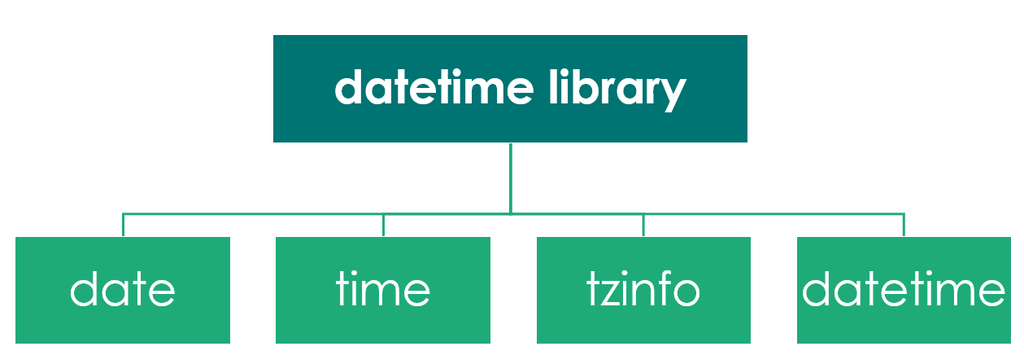



- The `datetime` is a built-in Python library that provides classes for manipulating dates and times. 

- The `datetime` library supports individual `date`, `time`, `datetime` and `tzinfo` classes.


- `date` class stores a date in the Gregorian calendar with attributes `year`, `month` and `day`.
- `time` class stores a simplified version of time with always 86,400 seconds in a day. Also the the attributes `hour`, `minute`, `second`, `microsecond` and `tzinfo` for time zone. 
- `datetime` class combines both `date` and `time` classes.([documentation](https://docs.python.org/3.7/library/datetime.html))



- By importing these specific classes from the datetime module, you can directly use them in your code.

In [1]:
# import all classes

from datetime import date, time, datetime, timezone

## ☑️ Declaring a `datetime` object

- To declare a `datetime` object at a minimum, the `datetime` must have an attached date. This is useful if you only want to consider dates rather than times.

- To consider time as well as date you additionally provide hour, minute and second arguments. You can be more specific down to the microsecond if desired. 

- We won't consider microseconds in this tutorial but the principle is the same. 

In [2]:
new_date = datetime(year=2020, month=6, day=23)
print(new_date)

2020-06-23 00:00:00


In [3]:
new_datetime = datetime(year=2020, month=6, day=23, hour=13, minute=6, second=30)
print(new_datetime)

2020-06-23 13:06:30


## ☑️ ISO 8601 Date and time Standard 


- ISO 8601 is an international standard for representing date and time information in a standardised format. 


- It defines a set of rules and formats for representing dates, times, and durations in a way that is universally understood and unambiguous.



- The ISO 8601 format for representing dates and times follows the pattern: 
`YYYY-MM-DDTHH:MM:SS`
    - `YYYY-MM-DD` for Year, Month and Day
    - `HH:MM:SS` Hour, Minute and Second
    -  **T** is the separator between the date and time components.


- Timezones are an **offset** from Coordinated Universal Time (UTC)
    - Indicated with a `+` or `-` **after** the time.
    
```python
iso_datetime         = "2020-06-23T16:58:30"
iso_datetime_with_tz = "2020-06-23T13:58:30+3"
iso_datetime_with_tz = "2020-06-23T13:58:30-5:30"
```
UTC offset of +3 means that the local time at that moment is three hours ahead of Coordinated Universal Time (UTC), where as UTC offset of -5:30 means that the local time at that moment is five hours and thirty minutes behind UTC. ([documentation](https://www.iso.org/iso-8601-date-and-time-format.html))

## ☑️ Declaring a `datetime` object with a timezone

In [4]:
from datetime import timezone

new_datetime_with_tz = datetime(year=2020, month=6, day=23,
                                hour=13, minute=58, second=30,
                                tzinfo=timezone.utc)
print(new_datetime_with_tz)

2020-06-23 13:58:30+00:00


Note that a timezone of `+0` is still a valid timezone.

We can also declare a `datetime` object with an associated timezone to localise the given time to specific area of the world. Here we use the default UTC timezone. Since this is the "central" timezone that other timezones are offset against, the actual time change is +0.

## ☑️ Working with datetime objects

Each attribute in a datetime object can be accessed using **dot** notation.

In [5]:
new_date = datetime(year=2020, month=6, day=23, hour=13, minute=58, second=30, tzinfo=timezone.utc)

# Inspecting date info
print(new_date.year)
print(new_date.month)
print(new_date.day)

# Inspecting time info
print(new_date.hour)
print(new_date.minute)
print(new_date.second)

# Inspecting timezone info
print(new_date.tzinfo)

2020
6
23
13
58
30
UTC


- If no time is given default value of midnight (`00:00:00`) will display.
- If no timezone is given (`None`) will display.

# Part 2 - Types of `datetime` objects

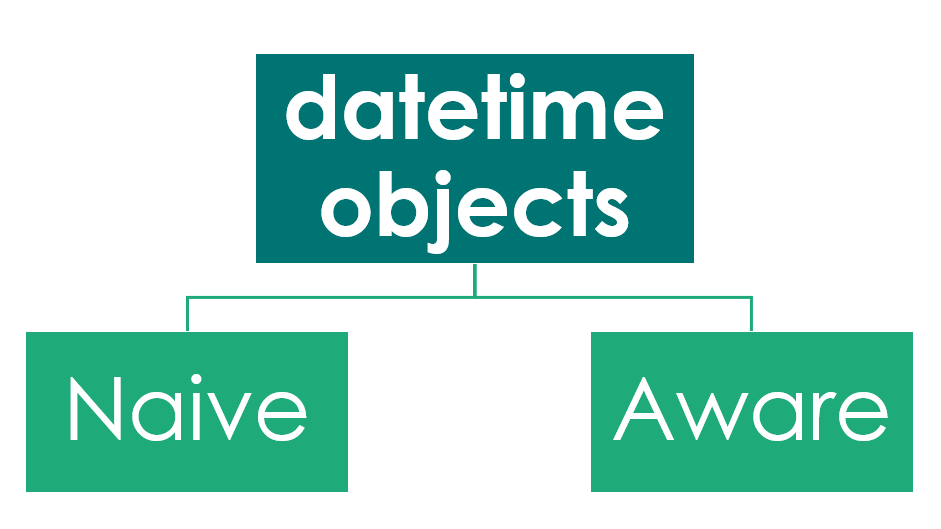

There are two kinds of `datetime` objects to consider: **Naive** and **Aware**

- You can use **naive** datetime objects most of the time if you don't know the timezone or it doesn't matter. 

- **Aware** datetime objects are useful if you need to co-ordinate times in multiple countries or international time differences.

## ☑️ **`Naive`** datetime objects example

- Naive objects are simple to create. However, they give no indication of _where_ the naive `datetime` is occuring which can cause problems if you are coordinating `datetime` objects over many timezones.


- This means that Python doesn't know if these objects have any associated location and the represented time is more abstract.


- Lets create **naive** datetime objects for `London` and `New York` time and check the difference.
Python interprets the difference between them as 18000 seconds (5 hours).

In [6]:
datetime_london = datetime(year=2020, month=1, day=18, hour=12, minute=0, second=0)

datetime_newyork = datetime(year=2020, month=1, day=18, hour=7, minute=0, second=0)

datetime_london - datetime_newyork

datetime.timedelta(seconds=18000)

## ☑️ **`Aware`** datetime objects example

Creating **aware** datetime objects means Python recognises these times are simultaneous in the real world. 

**Aware** `datetime` objects can embed the date and time you have in a specific global region. 

However **aware** datetime objects requires you to work with extra timezone packages to ensure you get what you want out. 

Here we use the `dateutil.tz` class to specify to `datetime` where each of these objects are occuring. As it turns out, these two times are happening simultaneously in the real world at different local times. Because we used `tzinfo` to inform `datetime` of this fact, Python recognises the real time elapsed between these objects is zero.

In [7]:
import dateutil.tz as tz

datetime_london_aware = datetime(year=2020, month=1, day=18, hour=12, minute=0, 
                                 second=0, tzinfo=tz.gettz("Europe/London"))

datetime_newyork_aware = datetime(year=2020, month=1, day=18, hour=7, minute=0, 
                                  second=0, tzinfo=tz.gettz("America/New_York"))

datetime_london_aware - datetime_newyork_aware

datetime.timedelta(0)

## ☑️ Changing **`Aware`** datetime objects timezone

In [8]:
datetime_hk = datetime.now(tz=tz.gettz("Asia/Hong_Kong"))
print(datetime_hk)

datetime_fr = datetime_hk.astimezone(tz.gettz("Europe/Paris"))
print(datetime_fr)

datetime_localised = datetime_hk.astimezone()
print(datetime_localised)

2026-08-17 01:38:45.075616+08:00
2026-08-16 19:38:45.075616+02:00
2026-08-16 17:38:45.075616+00:00


We can also convert aware datetimes between different timezones. If we want to localise an aware time to your computers time then the `.astimezone()` function can be called without an argument.

The `replace()` function can also be used to change a timezone in a `datetime` object, but only if the timezone needs to change without the local time changing. This would only change the offset and **not** convert a time to a different location. This is more appropriate if a timezone is wrong or a datetime needs to be recalibrated.

# Part 3 - Useful functions in `datetime` object

## ☑️ `datetime.today()`

`datetime.today()` returns the local datetime as a naive object.

In [9]:
print(datetime.today())

2026-08-16 17:38:45.116590


## ☑️ `datetime.now()`

`datetime.now()` similarly returns the local datetime but has an optional timezone argument.

In [10]:
print(datetime.now()) # Returns the same result as datetime.today()

print(datetime.now(tz=timezone.utc)) # Aware UTC datetime

print(datetime.now(tz=tz.gettz("Asia/Hong_Kong"))) # Aware datetime for Hong Kong

2026-08-16 17:38:45.126562
2026-08-16 17:38:45.126699+00:00
2026-08-17 01:38:45.126797+08:00


As well as creating datetime objects with specific arguments, there is also a set of useful functions in the `datetime` package. There are three similar functions for getting the current `datetime`. The first two are useful if you want your local date and time, or in another location. 

`datetime.today()` will give you your local date and time according to your computer. This is the easiest way to get the present datetime if needed. `datetime.now()` behaves the same way without any arguments but you can also use `datetime.now()` to get aware datetime objects in specific timezones. 

## ☑️ `datetime.utcnow()`

`datetime.utcnow()` returns the current UTC date and time as a naive datetime.

In [11]:
datetime.utcnow()

datetime.datetime(2026, 8, 16, 17, 38, 45, 138381)

## ☑️ `datetime.combine()`

`datetime.combine()` can combine a `date` and a `time`

In [12]:
this_date = date(2020,1,18)
this_time = time(23,59,59)
this_datetime = datetime.combine(this_date, this_time)
print(this_datetime)

2020-01-18 23:59:59


The `datetime.utcnow()` function is useful if you need to coordinate between time zones and need the global central time without any offsets.

The `datetime.combine()` function can also be useful to add date and time objects together. Note if your date is a datetime then the time object will override the original time.

## ☑️ `.weekday()` method for finding days of the week

- `datetime` library also stores the day of the week as an integer, this can be Accessed using `.weekday()` where Monday is `0` and Sunday is `6`.

- Alternatively you can also use built-in calendar` module` and `isoweekday()`. However for `isoweekday()` indexed starting from `1` to `7`

In [13]:
my_weekdays = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

wd_index = datetime.today().weekday()

print(wd_index)
print("Today is {}".format(my_weekdays[wd_index]))

6
Today is Sunday


# Part 4 - Arithmetic operations

## ☑️ Calculating time differences

- Calculate time difference using the `datetime.timedelta` class.

- This is a very useful class for operations on dates and times particularly if we need information about elapsed time or changes in time.

- The difference can be in **days**, **seconds**, **milliseconds**, **microseconds**, **minutes**, **hours**, **weeks**.

In [14]:
from datetime import timedelta

# Creating a timedelta object
duration = timedelta(weeks=12, days=5, hours=3, minutes=30, seconds=15)
print(duration)

89 days, 3:30:15


## ☑️ Performing arithmetic operations with `datetime` and `timedelta` objects

- You can then perform arithmetic operations such as addition and subtraction with `datetime` and `timedelta` objects.

- Operations between a datetime and a timedelta return **a new datetime**.

In [15]:
datetime_1 = datetime(year=2020, month=1, day=18, hour=12, minute=0, second=0)
datetime_2 = datetime(year=2016, month=3, day=11, hour=19, minute=0, second=0)
timedelta_1 = timedelta(weeks=13, seconds=456)

In [16]:
print(datetime_1 - datetime_2)

1407 days, 17:00:00


- Subtracting one `datetime` from another will give you the difference between the `datetime`. You cannot add two datetimes together. Any operation that returns a difference between `datetime` objects will be a `timedelta`. 

In [17]:
print(datetime_1 + timedelta_1)

2020-04-18 12:07:36


- Adding or subtracting a timedelta from a datetime object will give you a new `datetime` object with the original `datetime` changed by the value of the `timedelta`. 

## ☑️ Compare `datetime` objects

To compare datetime objects in Python, you can use comparison operators such as <, <=, >, >=, ==, and !=. These operators allow you to compare the values of datetime objects based on their dates and times.

Here's an example that demonstrates how to compare datetime objects:

In [18]:
datetime_1 = datetime(year=2020, month=1, day=18, hour=12, minute=0, second=0)
datetime_2 = datetime(year=2016, month=3, day=11, hour=19, minute=0, second=0)

print(datetime_1 == datetime_2)
print(datetime_1 != datetime_2)
print(datetime_1 > datetime_2)

False
True
True


# Part 5 - Formatting options

## ☑️ Formatting `datetime` objects


Up to now, our `datetime` objects were consistently printed in the standard ISO format. While this approach was informative, it may not always align with our desired output. To address this, we can employ formatting codes to tailor the representation of `datetime` objects according to our specific requirements.

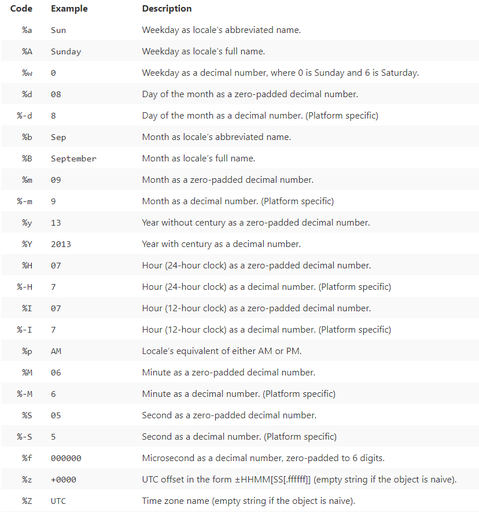

([Python strftime() cheatsheet](https://strftime.org/))

## ☑️ Formatting with `strftime()` examples

The `strftime()` method is a function available in the datetime module in Python that allows you to format a datetime object as a string based on a specified format code. The name `strftime` stands for "string format time."

In [19]:
dt = datetime(2020, 6, 6, 17, 59, 59)

# Print the date only
print(dt.strftime("%a %d %B, %Y"))

# A more American format
print(dt.strftime("%A %B %d, %Y %I:%M%p"))

# Using 24-hour time
print(dt.strftime("%A (%d %B %y) [%H:%M]"))

Sat 06 June, 2020
Saturday June 06, 2020 05:59PM
Saturday (06 June 20) [17:59]


## ☑️ Convert `string` to `datetime` objects with `dateutil`

The `dateutil` module provides a powerful date parsing function that can parse strings and convert them into `datetime` objects. Here's an example of how to import and use it:

In [20]:
from dateutil import parser

# Written date
new_date = parser.parse("13th October 2018")
print(new_date)

# UTC date
utc_date = parser.parse("2018-10-13T15:53:20")
print(utc_date)

2018-10-13 00:00:00
2018-10-13 15:53:20


## ☑️ Convert `string` to `datetime` objects with `strptime()`

The `strptime()` method is a function available in the datetime module in Python that allows you to convert a string representation of a date and time into a datetime object. The name strptime stands for "string parse time."

In [21]:
dt_string = "08-10-12[6:36]"    #This date is ambiguous

# Assume DD-MM-YY
print(datetime.strptime(dt_string, "%d-%m-%y[%H:%M]"))

# Assume MM-DD-YY
print(datetime.strptime(dt_string, "%m-%d-%y[%H:%M]"))

# Assume YY-MM-DD
print(datetime.strptime(dt_string, "%y-%m-%d[%H:%M]"))

2012-10-08 06:36:00
2012-08-10 06:36:00
2008-10-12 06:36:00


In [22]:
dt_string2 = "6:36PM on the 18th January 2020"    #This also works on written dates

print(datetime.strptime(dt_string2,"%I:%M%p on the %dth %B %Y"))

2020-01-18 18:36:00
